In [ ]:
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "Shawon16/VideoMAE_BdSLW401_20_epochs_p5_SR_10"
# Load model directly
from transformers import AutoImageProcessor, AutoModelForVideoClassification


batch_size = 4 # batch size for training and evaluation
from transformers import VideoMAEConfig, VideoMAEModel

# Initializing a VideoMAE videomae-base style configuration
configuration = VideoMAEConfig()

# Randomly initializing a model from the configuration
model = VideoMAEModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)

In [1]:
model_ckpt="facebook/timesformer-base-finetuned-k400"
#model_ckpt = "MCG-NJU/videomae-base" # pre-trained model from which to fine-tune
#model_ckpt = "google/vivit-b-16x2-kinetics400"
batch_size = 4 # batch size for training and evaluation
from transformers import TimesformerConfig, TimesformerModel

# Initializing a TimeSformer timesformer-base style configuration
configuration = TimesformerConfig()

# Initializing a model from the configuration
model = TimesformerModel(configuration)

# Accessing the model configuration
configuration = model.config
print(configuration)


/media/cse/HDD/Shawon/shawon/shawon_new/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /media/cse/HDD/Shawon/shawon/shawon_new/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")


TimesformerConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "attention_type": "divided_space_time",
  "drop_path_rate": 0,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "timesformer",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 8,
  "num_hidden_layers": 12,
  "patch_size": 16,
  "qkv_bias": true,
  "transformers_version": "4.46.1"
}



In [1]:
model_ckpt = "google/vivit-b-16x2-kinetics400"
batch_size = 4
from transformers import VivitConfig, VivitModel

# Initializing a ViViT google/vivit-b-16x2-kinetics400 style configuration
configuration = VivitConfig()

# Initializing a model (with random weights) from the google/vivit-b-16x2-kinetics400 style configuration
model = VivitModel(configuration)

# Accessing the model configuration
configuration = model.config

print(configuration)

/media/cse/HDD/Shawon/shawon/shawon_new/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /media/cse/HDD/Shawon/shawon/shawon_new/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warn(f"Failed to load image Python extension: {e}")


VivitConfig {
  "_attn_implementation_autoset": true,
  "attention_probs_dropout_prob": 0.0,
  "hidden_act": "gelu_fast",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 768,
  "image_size": 224,
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "layer_norm_eps": 1e-06,
  "model_type": "vivit",
  "num_attention_heads": 12,
  "num_channels": 3,
  "num_frames": 32,
  "num_hidden_layers": 12,
  "qkv_bias": true,
  "transformers_version": "4.46.1",
  "tubelet_size": [
    2,
    16,
    16
  ]
}



In [ ]:
import pathlib
output_root_path = pathlib.Path(r'/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected')

# Count videos in each set
video_count_train = len(list(output_root_path.glob("train/*/*.mp4")))
video_count_val = len(list(output_root_path.glob("val/*/*.mp4")))
video_count_test = len(list(output_root_path.glob("test/*/*.mp4")))

# Calculate total videos
video_total = video_count_train + video_count_val + video_count_test
print(f"Total videos: {video_total}")

# List all video file paths
all_video_file_paths = (
    list(output_root_path.glob("train/*/*.mp4")) +
    list(output_root_path.glob("val/*/*.mp4")) +
    list(output_root_path.glob("test/*/*.mp4"))
)

# Display the first five video file paths
print(all_video_file_paths[:5])

# Print total number of videos in each set and the first 5 video file paths for training
print(f"Total videos: {video_total}")
print(f"Training videos: {video_count_train}, Validation videos: {video_count_val}, Test videos: {video_count_test}")


Total videos: 9307
[PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected/train/cake/U3W44F_trial_12_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected/train/cake/U13W44F_trial_0_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected/train/cake/U13W44F_trial_1_L.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected/train/cake/U12W44F_trial_5_R.mp4'), PosixPath('/media/cse/HDD/Shawon/shawon/MY DATA/Val(U5)_Test(U4,U8)_Framerate corrected/train/cake/U13W44F_trial_8_L.mp4')]
Total videos: 9307
Training videos: 7431, Validation videos: 600, Test videos: 1276


In [18]:
# Adjust class label extraction logic
class_labels = sorted({str(path.parent.name) for path in all_video_file_paths})  # Use parent folder name as class label
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}
# Print the unique class labels and their mappings
print(f"Unique classes: {list(label2id.keys())}.")
print(f"Label to ID mapping: {label2id}")
print(f"ID to Label mapping: {id2label}")

Unique classes: ['aam', 'aaple', 'ac', 'aids', 'alu', 'anaros', 'angur', 'apartment', 'attio', 'audio cassette', 'ayna', 'baandej', 'baat', 'baba', 'balti', 'balu', 'bhai', 'biscuts', 'bon', 'boroi', 'bottam', 'bou', 'cake', 'capsule', 'cha', 'chacha', 'chachi', 'chadar', 'chal', 'chikissha', 'chini', 'chips', 'chiruni', 'chocolate', 'chokh utha', 'chosma', 'churi', 'clip', 'cream', 'dada', 'dadi', 'daeitto', 'dal', 'debor', 'denadar', 'dengue', 'doctor', 'dongson', 'dulavai', 'durbol', 'jomoj', 'juta', 'konna', 'maa', 'tattha', 'toothpaste', 'tshirt', 'tubelight', 'tupi', 'tv'].
Label to ID mapping: {'aam': 0, 'aaple': 1, 'ac': 2, 'aids': 3, 'alu': 4, 'anaros': 5, 'angur': 6, 'apartment': 7, 'attio': 8, 'audio cassette': 9, 'ayna': 10, 'baandej': 11, 'baat': 12, 'baba': 13, 'balti': 14, 'balu': 15, 'bhai': 16, 'biscuts': 17, 'bon': 18, 'boroi': 19, 'bottam': 20, 'bou': 21, 'cake': 22, 'capsule': 23, 'cha': 24, 'chacha': 25, 'chachi': 26, 'chadar': 27, 'chal': 28, 'chikissha': 29, 'chi

In [19]:
from transformers import VideoMAEImageProcessor, VideoMAEForVideoClassification
from transformers import VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification

# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

# image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,)
# image_processor = AutoImageProcessor.from_pretrained("Shawon16/VideoMAE_BdSLW401_20_epochs_p5_SR_10")
# model = AutoModelForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )

image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt,
    label2id=label2id,
    id2label=id2label,
    ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
)

import pytorchvideo.data

from pytorchvideo.transforms import (
    ApplyTransformToKey,
    Normalize,
    RandomShortSideScale,
    RemoveKey,
    ShortSideScale,
    UniformTemporalSubsample,
)

from torchvision.transforms import (
    Compose,
    Lambda,
    RandomCrop,
    RandomHorizontalFlip,
    Resize,
)

Some weights of VideoMAEForVideoClassification were not initialized from the model checkpoint at MCG-NJU/videomae-base-finetuned-kinetics and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([400]) in the checkpoint and torch.Size([60]) in the model instantiated
- classifier.weight: found shape torch.Size([400, 768]) in the checkpoint and torch.Size([60, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [20]:
import os
import os
import cv2  # Import OpenCV to handle video files
from pytorchvideo.data import make_clip_sampler, Ucf101
from torchvision.transforms import Compose
from transformers import VideoMAEForVideoClassification, VideoMAEConfig
from transformers import VivitConfig, VivitModel, VivitImageProcessor, VivitForVideoClassification
from transformers import AutoImageProcessor, TimesformerForVideoClassification


# Load the model configuration
model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#model_ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
#config = AutoModelForVideoClassification.from_pretrained(model_ckpt)
#model_ckpt = "facebook/timesformer-base-finetuned-k400"
#config = TimesformerForVideoClassification.from_pretrained(model_ckpt)

#model_ckpt = "google/vivit-b-16x2-kinetics400"
# config = VivitForVideoClassification.from_pretrained(model_ckpt)
#num_frames_to_sample = config.num_frames


mean = image_processor.image_mean
std = image_processor.image_std
if "shortest_edge" in image_processor.size:
    height = width = image_processor.size["shortest_edge"]
else:
    height = image_processor.size["height"]
    width = image_processor.size["width"]
resize_to = (height, width)

num_frames_to_sample = model.config.num_frames
print(f"Number of frames to sample: {num_frames_to_sample}")
sample_rate = 8
fps = 30
clip_duration = num_frames_to_sample * sample_rate / fps

# Training dataset transformations.
train_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                    RandomShortSideScale(min_size=256, max_size=320),
                    RandomCrop(resize_to),
                    RandomHorizontalFlip(p=0.5),
                    
                ]
            ),
        ),
    ]
)

# Training dataset.
train_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "train"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("random", clip_duration),
    decode_audio=False,
    transform=train_transform,
)



# Validation and evaluation datasets' transformations.
val_transform = Compose(
    [
        ApplyTransformToKey(
            key="video",
            transform=Compose(
                [
                    UniformTemporalSubsample(num_frames_to_sample),
                    Lambda(lambda x: x / 255.0),
                    Normalize(mean, std),
                    Resize(resize_to),
                ]
            ),
        ),
    ]
)

# Validation and evaluation datasets.
val_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "val"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

test_dataset = pytorchvideo.data.Ucf101(
    data_path=os.path.join(output_root_path, "test"),
    clip_sampler=pytorchvideo.data.make_clip_sampler("uniform", clip_duration),
    decode_audio=False,
    transform=val_transform,
)

Number of frames to sample: 16


In [21]:
train_dataset.num_videos, val_dataset.num_videos, test_dataset.num_videos

(7431, 600, 1276)

In [22]:
# train data sample
sample_video = next(iter(train_dataset))
sample_video.keys()

dict_keys(['video', 'video_name', 'video_index', 'clip_index', 'aug_index', 'label'])

In [23]:
def investigate_video(sample_video):
    """Utility to investigate the keys present in a single video sample."""
    for k in sample_video:
        if k == "video":
            print(k, sample_video["video"].shape)
        else:
            print(k, sample_video[k])

    print(f"Video label: {id2label[sample_video[k]]}")

investigate_video(sample_video)

video torch.Size([3, 16, 224, 224])
video_name U12W2F_trial_4_R.mp4
video_index 1044
clip_index 0
aug_index 0
label 8
Video label: attio


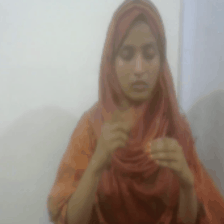

In [24]:
import imageio
import numpy as np
from IPython.display import Image


def unnormalize_img(img):
    """Un-normalizes the image pixels."""
    img = (img * std) + mean
    img = (img * 255).astype("uint8")
    return img.clip(0, 255)


def create_gif(video_tensor, filename="sample.gif"):
    """Prepares a GIF from a video tensor.
    
    The video tensor is expected to have the following shape:
    (num_frames, num_channels, height, width).
    """
    frames = []
    for video_frame in video_tensor:
        frame_unnormalized = unnormalize_img(video_frame.permute(1, 2, 0).numpy())
        frames.append(frame_unnormalized)
    kargs = {"duration": 0.25}
    imageio.mimsave(filename, frames, "GIF", **kargs)
    return filename


def display_gif(video_tensor, gif_name="sample.gif"):
    """Prepares and displays a GIF from a video tensor."""
    video_tensor = video_tensor.permute(1, 0, 2, 3)
    gif_filename = create_gif(video_tensor, gif_name)
    return Image(filename=gif_filename)

video_tensor = sample_video["video"]
display_gif(video_tensor)
#print(video_tensor.shape)

In [25]:
import evaluate
metric = evaluate.load("accuracy")
import torch

def compute_metrics(eval_pred):
    """Computes accuracy on a batch of predictions."""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    return metric.compute(predictions=predictions, references=eval_pred.label_ids)


def collate_fn(examples):
    """The collation function to be used by `Trainer` to prepare data batches."""
    # permute to (num_frames, num_channels, height, width)
    pixel_values = torch.stack(
        [example["video"].permute(1, 0, 2, 3) for example in examples]
    )
    labels = torch.tensor([example["label"] for example in examples])
    return {"pixel_values": pixel_values, "labels": labels}

In [ ]:
from huggingface_hub import login, hf_hub_download
# RnW token

# Authenticate using the API token
login(token=hf_token)

# ALL CoRelation PLOT BdSLW

In [ ]:
import os
from pathlib import Path
import cv2
import torch
import numpy as np
import evaluate
import pytorchvideo.data
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix
from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess
from transformers import (
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    VideoMAEImageProcessor,
    VideoMAEForVideoClassification,
)

# ------------------------
# Determinism / reproducibility
# ------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================
# Config & globals
# =========================
metric = evaluate.load("accuracy")
num_epochs = 20
batch_size = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

output_dir = f"/media/cse/HDD/Shawon/shawon/10 fold timesformer/videoMAE_BDSLW60_U5_20_coR_new"
output_dir = Path(output_dir)
output_dir.mkdir(parents=True, exist_ok=True)

train_dir = os.path.join(output_root_path, "train")
val_dir = os.path.join(output_root_path, "val")
test_dir = os.path.join(output_root_path, "test")

# sanity-check dataset folders (used for frequency computations only)
if not os.path.isdir(train_dir):
    raise RuntimeError(f"train_dir does not exist: {train_dir}")
if not os.path.isdir(val_dir):
    print(f"Warning: val_dir does not exist: {val_dir} (only train frequencies require folder structure)")

# Get class labels from train_dir (preserves ordering)
class_labels = [d for d in sorted(os.listdir(train_dir)) if os.path.isdir(os.path.join(train_dir, d))]
if len(class_labels) == 0:
    raise RuntimeError(f"No class folders found under train_dir: {train_dir}")

# label mappings
label2id = {label: i for i, label in enumerate(class_labels)}
id2label = {i: label for label, i in label2id.items()}

# =========================
# Plotting (PLOS ONE style)
# =========================
matplotlib.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

def plot_confusion_matrix(conf_matrix, class_labels, mode,
                          accuracy=None, precision=None, recall=None, f1=None, 
                          per_class_results=None, out_dir=output_dir):

    # ---------------------------
    # (PLOS) Font requirements
    # ---------------------------
    plt.rcParams['font.family'] = 'Times New Roman'   # Allowed fonts: Arial / Times / Symbol
    plt.rcParams['font.size'] = 10                    # Must be 8–12 pt

    plt.figure()

    fmt = ".1f" if not np.all(conf_matrix == conf_matrix.astype(int)) else "d"

    sns.heatmap(conf_matrix, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=class_labels, yticklabels=class_labels, 
                cbar_kws={"shrink": 0.8})

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)
    plt.xlabel("Predicted", fontsize=8)
    plt.ylabel("Actual", fontsize=8)

    # Mean metrics
    if isinstance(precision, np.ndarray): precision = precision.mean()
    if isinstance(recall, np.ndarray): recall = recall.mean()
    if isinstance(f1, np.ndarray): f1 = f1.mean()

    metrics_line = f"Acc: {accuracy:.3f}, Prec: {precision:.3f}, Rec: {recall:.3f}, F1: {f1:.3f}"
    plt.title(f"VideoMAE_BdSLW60 | {mode.upper()} | {metrics_line}", fontsize=10, weight="bold")

    # ---------------------------
    # (PLOS) Mandatory figure size
    # 7.5 in width = 2250 px at 300 dpi
    # Height capped to stay under PLOS limits
    # ---------------------------
    plt.gcf().set_size_inches(7.5, 8.0)   # PLOS-safe dimensions

    plt.tight_layout(pad=0.05)

    # ---------------------------
    # (PLOS) Save as TIFF with LZW compression
    # ---------------------------
    plt.savefig(
        out_dir / f"confusion_matrix_{mode}.tiff",
        format="tiff",
        dpi=300,                                 # Required 300–600 dpi
        pil_kwargs={"compression": "tiff_lzw"},  # Keeps file <10MB
        bbox_inches="tight",
        pad_inches=0.05
    )
    plt.close()

    # ---------------------------
    # Per-class accuracy bar chart
    # (same PLOS additions only)
    # ---------------------------
    if per_class_results:
        accuracy_per_class = per_class_results['accuracy_per_class']
        if isinstance(accuracy_per_class, dict):
            accuracy_per_class = [accuracy_per_class[c] for c in class_labels]

        # PLOS font rules apply globally — no changes here
        plt.figure(figsize=(7.5, 8.0))  # PLOS max width

        plt.bar(class_labels, accuracy_per_class)
        plt.xlabel('Class', fontsize=10)
        plt.ylabel('Accuracy', fontsize=10)
        plt.title(f'Per-Class Accuracy ({mode.upper()})', fontsize=12, weight='bold')
        plt.xticks(rotation=90)

        plt.tight_layout(pad=0.05)

        plt.savefig(
            out_dir / f"per_class_accuracy_{mode}.tiff",
            format="tiff",
            dpi=300,
            pil_kwargs={"compression": "tiff_lzw"},
            bbox_inches="tight",
            pad_inches=0.05
        )
        plt.close()

# =========================
# Collate function
# =========================
def collate_fn(examples):
    pixel_values = torch.stack([ex["video"].permute(1, 0, 2, 3) for ex in examples])
    labels = torch.tensor([ex["label"] for ex in examples])
    return {"pixel_values": pixel_values, "labels": labels}

# =========================
# Model setup
# =========================
image_processor = VideoMAEImageProcessor.from_pretrained(model_ckpt)
model = VideoMAEForVideoClassification.from_pretrained(
    model_ckpt, label2id=label2id, id2label=id2label, ignore_mismatched_sizes=True
).to(device)
# image_processor = VivitImageProcessor.from_pretrained("google/vivit-b-16x2-kinetics400")
# model = VivitForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,  # provide this in case you're planning to fine-tune an already fine-tuned checkpoint
# )
# image_processor = AutoImageProcessor.from_pretrained("facebook/timesformer-base-finetuned-k400")
# model = TimesformerForVideoClassification.from_pretrained(
#     model_ckpt,
#     label2id=label2id,
#     id2label=id2label,
#     ignore_mismatched_sizes=True,).to(device)
# =========================
# Long-tail plotting & correlation
# =========================
def plot_long_tail_performance_vs_class_frequency(
    class_labels,
    per_class_results,
    data_dir,
    mode,
    out_dir=output_dir,
    add_trendline=True,
    jitter_points=True,
    smooth_frac=0.35,
):
    os.makedirs(out_dir, exist_ok=True)

    acc_dict = per_class_results.get("accuracy_per_class", {})
    f1_dict  = per_class_results.get("f1", {})

    # Frequency depends on the provided data_dir
    freq = {}
    for c in class_labels:
        folder = os.path.join(data_dir, c)
        if os.path.isdir(folder):
            try:
                freq[c] = sum(os.path.isfile(os.path.join(folder, f)) for f in os.listdir(folder))
            except:
                freq[c] = 0
        else:
            freq[c] = 0

    df = pd.DataFrame({
        "class": class_labels,
        "freq": [freq[c] for c in class_labels],
        "accuracy": [acc_dict.get(c, np.nan) for c in class_labels],
        "f1": [f1_dict.get(c, np.nan) for c in class_labels],
    }).sort_values("freq", ascending=False).reset_index(drop=True)

    df["group"] = pd.qcut(df["freq"].rank(method="first"), 3, labels=["Tail", "Middle", "Head"])

    group_means = df.groupby("group")[["accuracy", "f1"]].mean()
    print("\n" + "="*60)
    print(f"[{mode.upper()}] Head/Middle/Tail Means:")
    print(group_means.to_string())
    print("="*60)

    # Spearman correlations
    r_acc, p_acc = spearmanr(df["freq"], df["accuracy"], nan_policy="omit")
    r_f1,  p_f1  = spearmanr(df["freq"], df["f1"],       nan_policy="omit")

    plos_width = 180 / 25.4
    fig_height = plos_width * 0.75

    def make_plot(metric, ylabel, r, p, fname):
        plt.figure(figsize=(plos_width, fig_height))

        for g, sub in df.groupby("group"):
            x = sub["freq"].values
            y = sub[metric].values

            if jitter_points:
                x = x + np.random.normal(0, max(1.0, x.std()*0.01), size=len(x))

            plt.scatter(x, y, alpha=0.8, s=25, label=f"{g} (n={len(sub)})")

        plt.xscale("log")
        plt.xlabel("Class Frequency (log scale)")
        plt.ylabel(ylabel)

        valid = df[["freq", metric]].dropna()
        valid = valid[valid["freq"] > 0]

        if len(valid) > 3:
            x_raw = valid["freq"].values
            x_log = np.log10(x_raw)
            y = valid[metric].values

            if add_trendline:
                A = np.polyfit(x_log, y, 1)
                xx = np.linspace(x_log.min(), x_log.max(), 300)
                yy = A[0]*xx + A[1]
                plt.plot(10**xx, yy, lw=1, color="black", alpha=0.9, label="Linear trend")

                sm = lowess(y, np.log10(x_raw), frac=smooth_frac, return_sorted=True)
                plt.plot(10**sm[:,0], sm[:,1], lw=1, alpha=0.9, color="gray", label="LOWESS")

        plt.title(
            f"{ylabel} vs Frequency ({mode.upper()})\n"
            f"Spearman r={r:.3f}, p={p:.3f}",
            fontsize=9, weight="bold",
        )
        plt.grid(alpha=0.3)
        plt.legend(frameon=False)
        plt.tight_layout()
        #plt.savefig(out_dir / fname, dpi=300, format="tiff", bbox_inches="tight")
        plt.savefig(os.path.join(output_dir, fname),
        dpi=300, format="tiff", pil_kwargs={"compression": "tiff_lzw"}, bbox_inches="tight")
        plt.close()

    make_plot("accuracy", "Class Accuracy", r_acc, p_acc, f"{mode}_longtail_accuracy.tiff")
    make_plot("f1",       "Class F1-Score", r_f1,  p_f1,  f"{mode}_longtail_f1.tiff")

    df.to_csv(out_dir / f"{mode}_longtail_data.csv", index=False)

    return r_acc, p_acc, r_f1, p_f1, df, group_means

# =========================
# Utility: compute avg frames per class
# =========================
def compute_avg_frames_per_class(split_dir, class_labels):
    avg_frames = {}
    for cls in class_labels:
        folder = os.path.join(split_dir, cls)
        frame_counts = []

        if not os.path.isdir(folder):
            avg_frames[cls] = 0
            continue

        for vid in os.listdir(folder):
            path = os.path.join(folder, vid)
            if not path.lower().endswith((".mp4", ".avi", ".mov", ".mkv")):
                continue
            try:
                cap = cv2.VideoCapture(path)
                frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                cap.release()
                frame_counts.append(frames)
            except:
                pass

        avg_frames[cls] = float(np.mean(frame_counts)) if len(frame_counts) > 0 else 0.0

    return avg_frames

# =========================
# Metrics computation from logits/labels (no trainer.predict inside)
# =========================
def compute_metrics_from_preds(logits, labels, class_labels):
    preds = np.argmax(logits, axis=1)
    accuracy = float((preds == labels).mean())

    precision, recall, f1, support = precision_recall_fscore_support(labels, preds, average=None, zero_division=0)

    accuracy_per_class = {
        class_labels[i]: float(np.mean(preds[labels == i] == i)) if (labels == i).sum() > 0 else 0.0
        for i in range(len(class_labels))
    }

    # Top-5 accuracy (handles cases with fewer than 5 classes)
    k = min(5, logits.shape[1])
    topk = np.argsort(logits, axis=1)[:, -k:]
    top5_acc = sum(l in row for l, row in zip(labels, topk)) / len(labels) if len(labels) > 0 else 0.0

    conf_matrix = confusion_matrix(labels, preds)

    per_class_results = {
        'accuracy_per_class': accuracy_per_class,
        'precision': {class_labels[i]: float(precision[i]) for i in range(len(class_labels))},
        'recall': {class_labels[i]: float(recall[i]) for i in range(len(class_labels))},
        'f1': {class_labels[i]: float(f1[i]) for i in range(len(class_labels))},
        'support': {class_labels[i]: int(support[i]) for i in range(len(class_labels))}
    }

    return accuracy, precision, recall, f1, conf_matrix, per_class_results, float(top5_acc), preds


# =========================
# Training
# =========================
max_steps = (train_dataset.num_videos // (2 * 4)) * num_epochs if hasattr(train_dataset, "num_videos") else -1
args = TrainingArguments(
    output_dir=str(output_dir), remove_unused_columns=False,
    save_strategy="epoch", evaluation_strategy="epoch",
    learning_rate=5e-5, per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size, gradient_accumulation_steps=4,
    warmup_ratio=0.1, logging_strategy="epoch", max_steps=max_steps if max_steps>0 else None,
    load_best_model_at_end=True, metric_for_best_model="accuracy",
    num_train_epochs=num_epochs, report_to=["none"], fp16=True,
    weight_decay=0.01, push_to_hub=True,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": metric.compute(predictions=preds, references=labels)["accuracy"]}

trainer = Trainer(
    model=model, args=args, train_dataset=train_dataset, eval_dataset=val_dataset,
    tokenizer=image_processor, compute_metrics=compute_metrics,
    data_collator=collate_fn, callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

print("Training started (Fixed Split)")
trainer.train()
trainer.save_state()
trainer.save_model()

# =========================
# Evaluate train, val, test (single predict per dataset; reuse results)
# =========================
results = {}
avg_frames_map = {
    "train": compute_avg_frames_per_class(train_dir, class_labels),
    "val":   compute_avg_frames_per_class(val_dir, class_labels),
    "test":  compute_avg_frames_per_class(test_dir, class_labels)
}
print("✔ Done: Average frame counts computed once per split.")

datasets = [("train", train_dataset, train_dir), ("val", val_dataset, val_dir), ("test", test_dataset, test_dir)]
predictions_cache = {}

for mode, dataset, data_dir in datasets:
    print(f"Predicting on {mode} dataset...")
    
    pred_out = trainer.predict(dataset)
    # free cached GPU memory to avoid possible OOM on repeated predicts
    try:
        torch.cuda.empty_cache()
    except Exception:
        pass

    y_pred = np.argmax(pred_out.predictions, axis=1)
    y_true = pred_out.label_ids


    logits = pred_out.predictions
    labels = pred_out.label_ids
    filenames = [sample["video_name"] for sample in dataset]  # relies on dataset providing "video_name"

    acc, prec, rec, f1, cm, per_class_results, top5, preds = compute_metrics_from_preds(logits, labels, class_labels)
    results[mode] = acc

    # Save plots & CSVs
    plot_confusion_matrix(cm, class_labels, mode, acc, prec, rec, f1, per_class_results, out_dir=output_dir)
    spearman_acc_r, spearman_acc_p, spearman_f1_r, spearman_f1_p, longtail_df, group_means = \
        plot_long_tail_performance_vs_class_frequency(class_labels, per_class_results, data_dir, mode, out_dir=output_dir, add_trendline=True)

    avg_frames = avg_frames_map[mode]

    # Save per-class results CSV
    rows = []
    for c in class_labels:
        rows.append({
            "class": c,
            "accuracy": per_class_results['accuracy_per_class'][c],
            "precision": per_class_results['precision'][c],
            "recall": per_class_results['recall'][c],
            "f1": per_class_results['f1'][c],
            "top5_accuracy": top5,
            "support": per_class_results["support"].get(c, 0),
            "avg_frames": avg_frames.get(c, 0),
        })
    pd.DataFrame(rows).to_csv(output_dir / f"per_class_results_{mode}.csv", index=False)
    print(f"✅ {mode.upper()} per-class results saved.")

# plotting accuracy vs avg frames (kept same, but uses df created here)
    df = pd.DataFrame(rows)

    # compute correlations
    from scipy.stats import spearmanr, pearsonr
    x = df["avg_frames"].values
    y = df["accuracy"].values
    spearman_r, spearman_p = spearmanr(x, y)
    pearson_r, pearson_p = pearsonr(x, y)
    print(f"📈 Spearman correlation (acc vs avg_frames): r={spearman_r:.4f}, p={spearman_p:.4g}")
    print(f"📈 Pearson correlation  (acc vs avg_frames): r={pearson_r:.4f}, p={pearson_p:.4g}")

    plt.figure(figsize=(8, 5))
    class_ids = pd.factorize(df["class"])[0]
    jitter_x = df["avg_frames"] + np.random.normal(0, 0.8, size=len(df))
    y = df["accuracy"].values

    plt.scatter(jitter_x, y, c=class_ids, cmap="tab20", s=8, alpha=0.7, edgecolor="none")

    # ---- regression line ----
    coeffs = np.polyfit(df["avg_frames"].values, df["accuracy"].values, 1)
    poly_fn = np.poly1d(coeffs)
    x_sorted = np.sort(df["avg_frames"].values)
    plt.plot(x_sorted, poly_fn(x_sorted), color="black", linewidth=1.5, alpha=0.8)
    # -------------------------

    plt.xlabel("Average Frames per Class")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy vs Average Frames ({mode.upper()})")

    # correlation on plot
    plt.text(
        0.02, 0.02,
        f"Spearman r={spearman_r:.3f}, p={spearman_p:.3g}\n"
        f"Pearson  r={pearson_r:.3f}, p={pearson_p:.3g}",
        transform=plt.gca().transAxes,
        fontsize=10,
        va="bottom",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    plt.grid(True, alpha=0.3)
    cbar = plt.colorbar()
    cbar.set_label("Class Index")
    plt.tight_layout()

    plot_path = os.path.join(output_dir, f"accuracy_vs_avg_frames_{mode}.tiff")
    plt.savefig(plot_path, dpi=300, format="tiff")
    plt.close()

    print(f"📊 Saved Accuracy vs Avg Frames plot to: {plot_path}")
    print(f"📊 Saved Accuracy vs Avg Frames plot to: {plot_path}")


    # Store for reuse (signer stats)
    predictions_cache[mode] = {"labels": labels, "preds": preds, "filenames": filenames, "per_class_results": per_class_results}
       

# ------------------------------------------------------
# Signer-wise statistics and plots
# ------------------------------------------------------
def extract_signer_id(filename):
    base = os.path.basename(filename)
    signer = base.split("W")[0]   # everything before first 'W'
    return signer

def get_signer_wise_stats(y_true, y_pred, filenames, extract_signer_id):
    signer_stats = {}
    for true, pred, fname in zip(y_true, y_pred, filenames):
        signer = extract_signer_id(fname)
        if signer not in signer_stats:
            signer_stats[signer] = {"correct": 0, "total": 0}
        signer_stats[signer]["total"] += 1
        if true == pred:
            signer_stats[signer]["correct"] += 1
    return signer_stats
def compute_unique_signers_per_class(y_true, filenames, extract_signer_id, class_labels):
    """
    Count how many unique signers contributed samples to each class.
    One signer is counted once per class, regardless of frequency.
    """
    class_to_signers = {cls: set() for cls in class_labels}

    for true_label, fname in zip(y_true, filenames):
        signer = extract_signer_id(fname)
        cls = class_labels[true_label]
        class_to_signers[cls].add(signer)

    # convert to integer counts
    return {cls: len(signers) for cls, signers in class_to_signers.items()}


def save_signer_accuracy(signer_stats, out_dir, mode):

    # ---------------------------
    # (PLOS) Font requirements
    # ---------------------------
    plt.rcParams['font.family'] = 'Times New Roman'   # Allowed fonts
    plt.rcParams['font.size'] = 10                    # Must be 8–12 pt

    signer_rows = []
    for signer, stats in signer_stats.items():
        acc = stats["correct"] / stats["total"] if stats["total"] > 0 else 0
        signer_rows.append({
            "signer": signer,
            "accuracy": acc,
            "total_samples": stats["total"],
            "correct_predictions": stats["correct"],
        })

    df_signer = pd.DataFrame(signer_rows).sort_values("signer")
    signer_csv_path = os.path.join(out_dir, f"per_singer_results_{mode}.csv")
    df_signer.to_csv(signer_csv_path, index=False)
    print(f"📁 Saved per-signer accuracy to: {signer_csv_path}")

    # ---------------------------
    # (PLOS) Figure size limits
    # Keep width ≤ 7.5 in (2250 px), height reasonable
    # ---------------------------
    plt.figure(figsize=(7.5, 5.5))

    plt.scatter(df_signer["signer"], df_signer["accuracy"], s=30)
    plt.xticks(rotation=45, fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel("Signer ID", fontsize=12)
    plt.ylabel("Accuracy", fontsize=12)
    plt.title(f"Accuracy vs Signer ({mode.upper()})", fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plot_path = os.path.join(out_dir, f"accuracy_vs_signer_{mode}.tiff")

    # ---------------------------
    # (PLOS) TIFF + LZW Compression + 300 dpi
    # ---------------------------
    plt.savefig(
        plot_path,
        dpi=300,
        format="tiff",
        pil_kwargs={"compression": "tiff_lzw"},
        bbox_inches="tight",
        pad_inches=0.05
    )

    plt.close()
    print(f"📊 Saved PLOS ONE TIFF figure to: {plot_path}")
    return df_signer



def save_accuracy_vs_unique_signer_count_plot(class_signer_map, per_class_results, out_dir, mode):
    """
    Plot accuracy vs number of unique signers per class.
    Saves both CSV and TIFF (PLOS ONE format).
    """

    # ---------------------------
    # (PLOS) Font requirements
    # ---------------------------
    plt.rcParams['font.family'] = 'Times New Roman'   # Allowed font
    plt.rcParams['font.size'] = 10                    # 8–12 pt required

    rows = []
    for cls, num_signers in class_signer_map.items():
        acc = per_class_results["accuracy_per_class"].get(cls, np.nan)
        rows.append({
            "class": cls,
            "unique_signers": num_signers,
            "accuracy": acc
        })
    
    df = pd.DataFrame(rows)
    
    # Save CSV
    csv_path = os.path.join(out_dir, f"accuracy_vs_unique_signers_{mode}.csv")
    df.to_csv(csv_path, index=False)
    print(f"📁 Saved accuracy-vs-unique-signers CSV: {csv_path}")

    from scipy.stats import spearmanr, pearsonr
    x = df["unique_signers"].values
    y = df["accuracy"].values

    spear_r, spear_p = spearmanr(x, y)
    pear_r, pear_p = pearsonr(x, y)

    print(f"📈 Spearman r={spear_r:.4f}, p={spear_p:.4g}")
    print(f"📈 Pearson  r={pear_r:.4f}, p={pear_p:.4g}")

    # ---------------------------
    # (PLOS) Figure size
    # max width 7.5 inches
    # ---------------------------
    plt.figure(figsize=(7.5, 5.0))

    # Jitter only for scatter visibility
    jitter_x = x + np.random.normal(0, 0.12, size=len(x))

    plt.scatter(jitter_x, y, s=35, alpha=0.75)

    # Regression line
    coeffs = np.polyfit(x, y, 1)
    poly = np.poly1d(coeffs)
    xs = np.linspace(min(x), max(x), 200)
    plt.plot(xs, poly(xs), color="black", linewidth=1.5)

    plt.xlabel("Number of Unique Signers per Class", fontsize=12)
    plt.ylabel("Class Accuracy", fontsize=12)
    plt.title(f"Accuracy vs Unique Signers per Class ({mode.upper()})", fontsize=12)

    # Correlation text
    plt.text(
        0.02, 0.02,
        f"Spearman r={spear_r:.3f}, p={spear_p:.3g}\n"
        f"Pearson  r={pear_r:.3f}, p={pear_p:.3g}",
        transform=plt.gca().transAxes,
        fontsize=10,
        va="bottom",
        ha="left",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    # Integer x-axis
    plt.gca().xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
    plt.xticks(sorted(set(x)), fontsize=10)

    plt.grid(alpha=0.3)
    plt.tight_layout()

    # ---------------------------
    # (PLOS) Save TIFF with LZW compression
    # ---------------------------
    out_tiff = os.path.join(out_dir, f"accuracy_vs_unique_signers_{mode}.tiff")
    plt.savefig(
        out_tiff,
        dpi=300,
        format="tiff",
        pil_kwargs={"compression": "tiff_lzw"},
        bbox_inches="tight",
        pad_inches=0.05
    )
    plt.close()

    print(f"📊 Saved PLOS ONE TIFF figure to: {out_tiff}")



# Run for train/val/test using cached predictions
for mode in ["train", "val", "test"]:
    cache = predictions_cache[mode]

    # 1) signer-wise accuracy
    signer_stats = get_signer_wise_stats(
        cache["labels"], cache["preds"], cache["filenames"], extract_signer_id
    )
    save_signer_accuracy(signer_stats, str(output_dir), mode)

    # 2) unique signer count per class
    class_signer_map = compute_unique_signers_per_class(
        cache["labels"], cache["filenames"], extract_signer_id, class_labels
    )

    # 3) accuracy vs unique signer count
    per_class_results = cache["per_class_results"]   # ← Now works

    save_accuracy_vs_unique_signer_count_plot(
        class_signer_map,
        per_class_results,
        output_dir,
        mode
    )

print("\n=== Final Results ===")
print(f"Train Accuracy: {results['train']:.4f}")
print(f"Val Accuracy:   {results['val']:.4f}")
print(f"Test Accuracy:  {results['test']:.4f}")
trainer.push_to_hub()
